KPIS

1.	Which Region contributes the most to total sales?
2.	What are the Top 10 States by total sales?
3.	Which City has the highest sales?
4.	Which Segment contributes the most to overall Sales?
5.	Which Segment contributes the most to the overall sales percentage?
6.	Within each Segment, which Sub-Category generates the most Sales?
7.	Which State has the highest Profit and which one has the highest Loss?
8.	Which Sub-Category contributes the most to overall sales percentage?
9.	Which State has the highest number of orders?
10.	Which City has the highest number of orders?
11.	Which Sub-Category has the highest sales?
12.	Monthly Sales Trend
13.	Top 10 Customers by Sales
14.	Region-wise Sales Contribution
15.	(Duplicate) Which Region contributes the most to total sales?
16.	Which Sub-Category contributes the most to sales?
17.	Which Ship Mode is most used by customers?
18.	Which Customer made the highest purchase (by Sales)?
19.	Which Customer made the highest number of Orders?
20.	Yearly Sales Growth Trend
21.	Sales Contribution by Ship Mode
22.	Sales Distribution Plot (insight text)
23.	Time Series Decomposition — additive model
24.	Time Series Decomposition — multiplicative model
25.	ADF test result (stationarity check)
26.	ACF & PACF plots
27.	Model Building (ARIMA, SARIMA)
28.	Forecasting (with comparison ARIMA vs SARIMA)

In [126]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [127]:
df = pd.read_csv('stores_sales_forecasting.csv', encoding="ISO-8859-1")
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [128]:
df['Row ID'].duplicated().sum()

np.int64(0)

In [129]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [130]:
df = df.drop('Postal Code', axis=1)
df.head(5)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,06-09-2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Region         2121 non-null   object 
 12  Product ID     2121 non-null   object 
 13  Category       2121 non-null   object 
 14  Sub-Category   2121 non-null   object 
 15  Product Name   2121 non-null   object 
 16  Sales          2121 non-null   float64
 17  Quantity       2121 non-null   int64  
 18  Discount

In [132]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format="mixed", errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'], format="mixed", errors='coerce')
# corce is used to instruct the pandas compiler any value which is unable to convert into coerce convert into missing or invalid value


df.head(15)



,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,2014-06-09,2014-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,California,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092
5,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,Pennsylvania,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
6,25,CA-2015-106320,2015-09-25,2015-09-30,Standard Class,EB-13870,Emily Burns,Consumer,United States,Orem,Utah,West,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,1044.6300,3,0.00,240.2649
7,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522
8,30,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,Pennsylvania,East,FUR-FU-10004848,Furniture,Furnishings,"Howard Miller 13-3/4"" Diameter Brushed Chrome ...",124.2000,3,0.20,15.5250
9,37,CA-2016-117590,2016-12-08,2016-12-10,First Class,GH-14485,Gene Hale,Corporate,United States,Richardson,Texas,Central,FUR-FU-10003664,Furniture,Furnishings,"Electrix Architect's Clamp-On Swing Arm Lamp, ...",190.9200,5,0.60,-147.9630


In [133]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         2121 non-null   int64         
 1   Order ID       2121 non-null   object        
 2   Order Date     2121 non-null   datetime64[ns]
 3   Ship Date      2121 non-null   datetime64[ns]
 4   Ship Mode      2121 non-null   object        
 5   Customer ID    2121 non-null   object        
 6   Customer Name  2121 non-null   object        
 7   Segment        2121 non-null   object        
 8   Country        2121 non-null   object        
 9   City           2121 non-null   object        
 10  State          2121 non-null   object        
 11  Region         2121 non-null   object        
 12  Product ID     2121 non-null   object        
 13  Category       2121 non-null   object        
 14  Sub-Category   2121 non-null   object        
 15  Product Name   2121 n

In [134]:
df.shape

(2121, 20)

In [135]:
df.columns.tolist() # making the columns into a list 


['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales',
 'Quantity',
 'Discount',
 'Profit']

**# 1) Which Region contributes the most to total sales?**

In [136]:
# Grouping sales by Region

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

# Display results
print("Total Sales by Region:\n", region_sales)


Total Sales by Region:
 Region
West       252612.7435
East       208291.2040
Central    163797.1638
South      117298.6840
Name: Sales, dtype: float64


Here we can observe west region has most number of sales


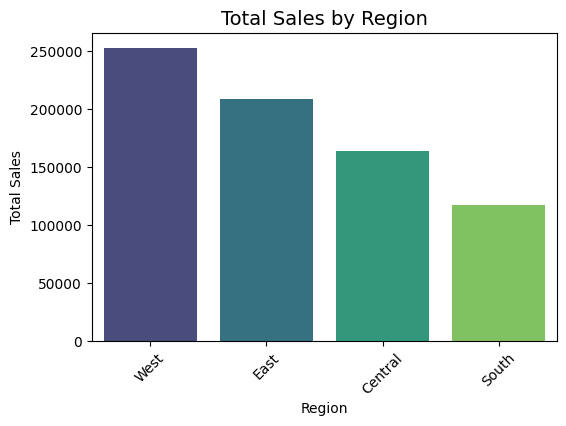

In [137]:
plt.figure(figsize=(6,4))
sns.barplot(x=region_sales.index, y=region_sales.values, palette="viridis")

plt.title("Total Sales by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

**#2)What are the Top 10 States by total sales?**

In [138]:
# Group sales by State

state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False)

# Top 10 States

top10_states = state_sales.head(10)

print("Top 10 States by Total Sales:\n", top10_states)


Top 10 States by Total Sales:
 State
California      156064.6015
New York         93372.7290
Texas            60593.2918
Washington       48020.1520
Pennsylvania     39354.9310
Illinois         28274.5220
Virginia         25321.9500
Ohio             24199.1450
Florida          22987.0380
Michigan         22321.1000
Name: Sales, dtype: float64


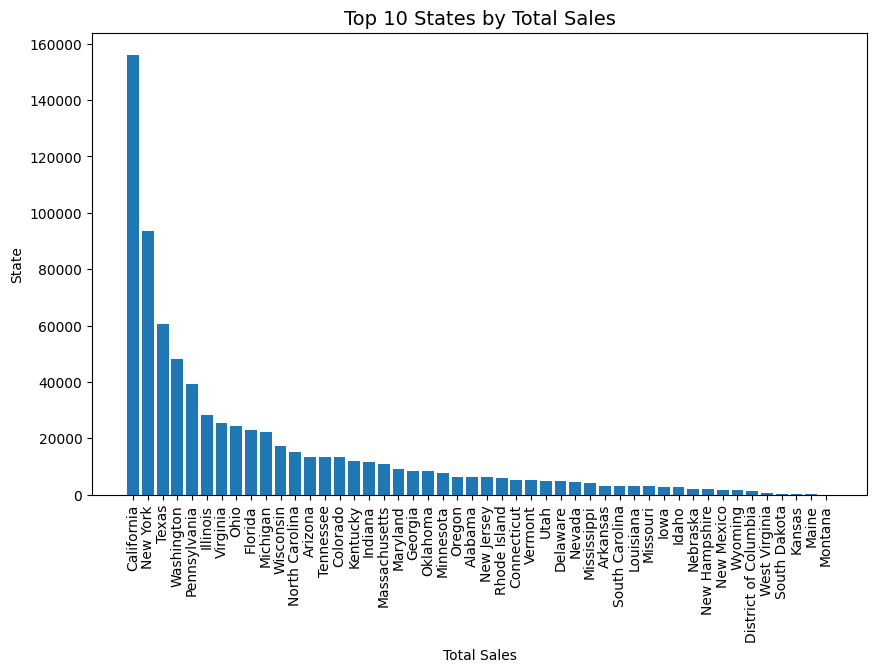

In [139]:
plt.figure(figsize=(10,6))
plt.bar(state_sales.index,state_sales.values)
plt.title("Top 10 States by Total Sales", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.xticks(rotation=90)

plt.show()


#3)Which City has the highest sales?

In [140]:

city_sales = df.groupby("City")[["Sales"]].sum().sort_values(by="Sales", ascending=False)

# Top 10 Cities

top10_cities = city_sales.head(10).reset_index()

print("Top 10 Cities by Total Sales:\n", top10_cities)


Top 10 Cities by Total Sales:
             City       Sales
0  New York City  75691.0490
1    Los Angeles  54000.0410
2        Seattle  40995.8780
3   Philadelphia  36495.5410
4  San Francisco  36357.3080
5        Houston  23183.2144
6      San Diego  20031.2370
7        Detroit  16364.0100
8        Chicago  12495.2220
9    Springfield  12046.1980


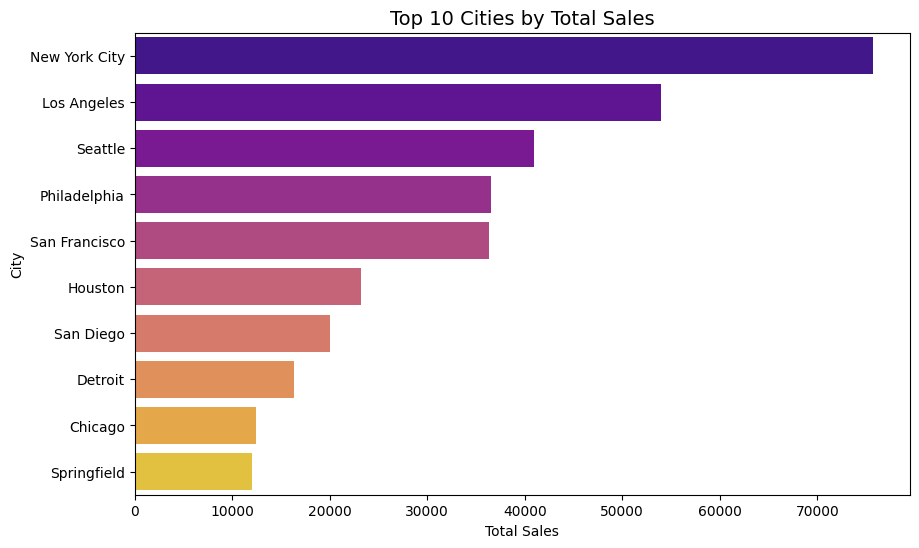

In [141]:
plt.figure(figsize=(10,6))
sns.barplot(x="Sales", y="City", data=top10_cities, palette="plasma")

plt.title("Top 10 Cities by Total Sales", fontsize=14)
plt.xlabel("Total Sales")
plt.ylabel("City")
plt.show()


### Which Segment contributes the most to overall Sales?

In [142]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [143]:
df['Category'].value_counts()

Category
Furniture    2121
Name: count, dtype: int64

In [144]:
# Group sales by Segment

Segment_sales = df.groupby("Segment")[["Sales"]].sum().sort_values(by="Sales", ascending=False)

# Reset index for DataFrame

Segment_sales =Segment_sales.reset_index()

print("Total Sales by Segment:\n",Segment_sales)


Total Sales by Segment:
        Segment        Sales
0     Consumer  391049.3120
1    Corporate  229019.7858
2  Home Office  121930.6975


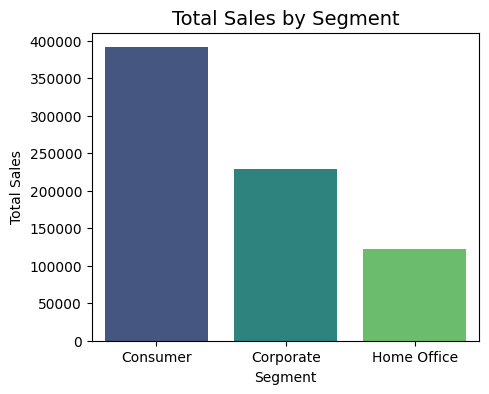

In [145]:
plt.figure(figsize=(5,4))
sns.barplot(x="Segment", y="Sales", data=Segment_sales, hue="Segment", palette="viridis", legend=False)

plt.title("Total Sales by Segment", fontsize=14)
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()


### Which Segment contributes the most to the overall sales percentage?

In [146]:
# Group sales by Segment
Segment_sales = df.groupby("Segment")[["Sales"]].sum().sort_values(by="Sales", ascending=False)

# Reset index for proper DataFrame
Segment_sales = Segment_sales.reset_index()

print("Sales Contribution by Segment (%):\n", Segment_sales)


Sales Contribution by Segment (%):
        Segment        Sales
0     Consumer  391049.3120
1    Corporate  229019.7858
2  Home Office  121930.6975


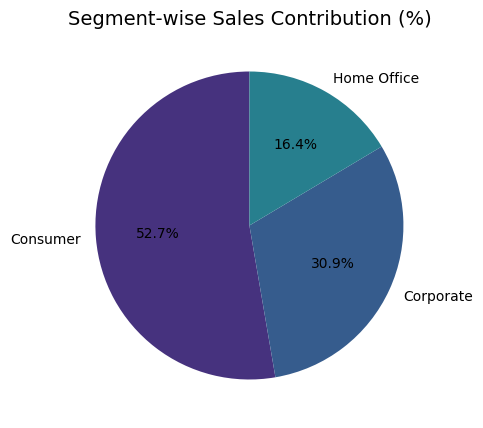

In [147]:
plt.figure(figsize=(5,5))
plt.pie(Segment_sales["Sales"], labels=Segment_sales["Segment"], 
        autopct="%.1f%%", startangle=90, colors=sns.color_palette("viridis"))

plt.title("Segment-wise Sales Contribution (%)", fontsize=14)
plt.show()


In [148]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

### Within each Segment, which Sub-Category generates the most Sales?

In [149]:
subcategory_sales = df.groupby(['Segment','Sub-Category'])[['Sales']].sum().sort_values(by='Segment',ascending=False)
subcategory_sales = subcategory_sales.reset_index()

print("Sales b Segment and Sub-Category:\n", subcategory_sales)

Sales b Segment and Sub-Category:
         Segment Sub-Category        Sales
0   Home Office    Bookcases   12241.3430
1   Home Office       Chairs   56445.4830
2   Home Office  Furnishings   17083.8520
3   Home Office       Tables   36160.0195
4     Corporate    Bookcases   34005.9243
5     Corporate       Chairs   99140.8780
6     Corporate  Furnishings   25001.2660
7     Corporate       Tables   70871.7175
8      Consumer    Bookcases   68632.7290
9      Consumer       Chairs  172862.7420
10     Consumer  Furnishings   49620.0460
11     Consumer       Tables   99933.7950


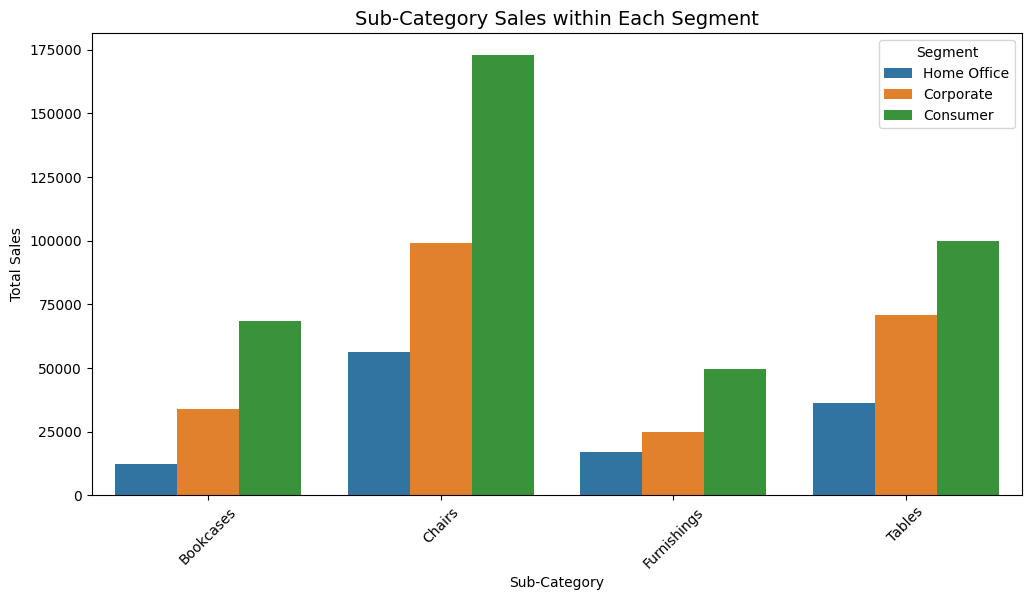

In [150]:
plt.figure(figsize=(12,6))
sns.barplot(x="Sub-Category", y="Sales", hue="Segment", data=subcategory_sales, palette="tab10")

plt.title("Sub-Category Sales within Each Segment", fontsize=14)
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()


### Which State has the highest Profit and which one has the highest Loss?

In [29]:
df.head(1)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136


In [30]:
# Group profit by State
state_profit = df.groupby("State")[["Profit"]].sum().sort_values(by="Profit", ascending=False)

# Reset index for DataFrame
state_profit = state_profit.reset_index()

# Top 5 Profit States
top5_profit_states = state_profit.head(5)

# Bottom 5 Loss States
bottom5_loss_states = state_profit.tail(5)

print("Top 5 States by Profit:\n", top5_profit_states)
print("\nBottom 5 States by Loss:\n", bottom5_loss_states)


Top 5 States by Profit:
         State     Profit
0  California  9162.9656
1  Washington  7193.7850
2    New York  5857.6801
3    Virginia  5204.3265
4    Michigan  4675.5516

Bottom 5 States by Loss:
              State      Profit
43  North Carolina  -3486.4633
44            Ohio  -4206.3212
45    Pennsylvania  -7196.7199
46        Illinois  -9076.2894
47           Texas -10436.1419


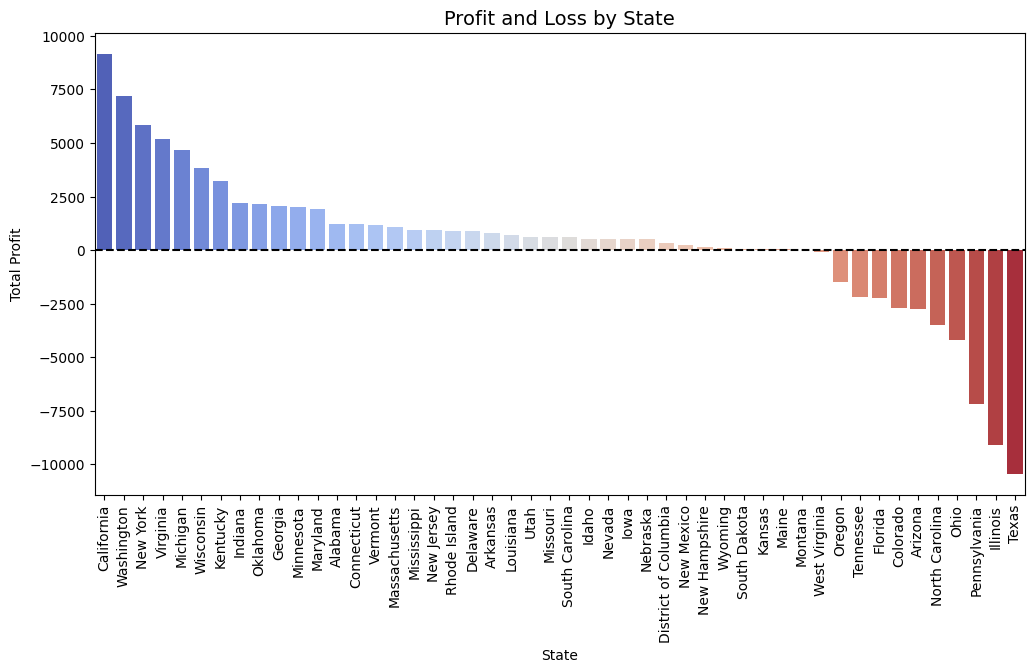

In [31]:
plt.figure(figsize=(12,6))
sns.barplot(x="State", y="Profit", data=state_profit, palette="coolwarm")

plt.title("Profit and Loss by State", fontsize=14)
plt.xlabel("State")
plt.ylabel("Total Profit")
plt.xticks(rotation=90)
plt.axhline(0, color="black", linestyle="--")
plt.show()


### Which Sub-Category contributes the most to the overall sales percentage?

Sub-Category Contribution to Sales:
   Sub-Category        Sales    Sales %
1       Chairs  328449.1030  44.265390
3       Tables  206965.5320  27.892937
0    Bookcases  114879.9963  15.482484
2  Furnishings   91705.1640  12.359190


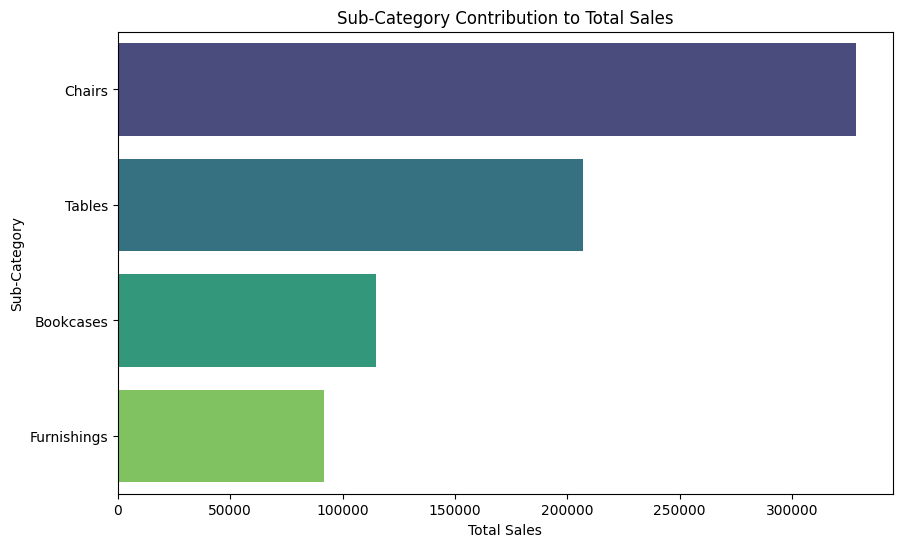

In [32]:
# Sub-Category-wise sales

subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index()

# Calculate percentage contribution

subcategory_sales["Sales %"] = (subcategory_sales["Sales"] / subcategory_sales["Sales"].sum()) * 100

# Sort by Sales

subcategory_sales = subcategory_sales.sort_values(by="Sales", ascending=False)

print("Sub-Category Contribution to Sales:\n", subcategory_sales)

# Visualization

plt.figure(figsize=(10,6))
sns.barplot(x="Sales", y="Sub-Category", data=subcategory_sales, palette="viridis")
plt.title("Sub-Category Contribution to Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()


### Q8: Which State has the highest number of orders?

Orders by State:
            State  Order ID
3     California       377
30      New York       196
40         Texas       175
44    Washington       101
35  Pennsylvania        99
11      Illinois        98
32          Ohio        76
8        Florida        68
43      Virginia        45
20      Michigan        40


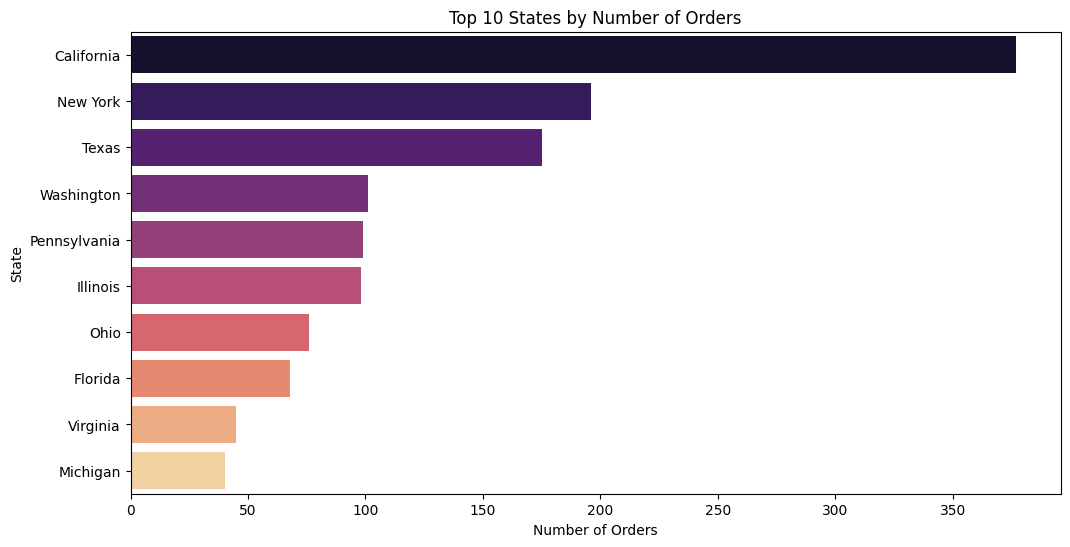

In [33]:

# Count orders per state
state_orders = df.groupby("State")["Order ID"].nunique().reset_index()

# Sort in descending order
state_orders = state_orders.sort_values(by="Order ID", ascending=False)

print("Orders by State:\n", state_orders.head(10))

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x="Order ID", y="State", data=state_orders.head(10), palette="magma")
plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")
plt.show()


### Which City has the highest number of orders?

Orders by City:
               City  Order ID
232  New York City       157
184    Los Angeles       138
307  San Francisco        91
264   Philadelphia        89
316        Seattle        84
146        Houston        68
54         Chicago        56
66        Columbus        40
306      San Diego        36
76          Dallas        24


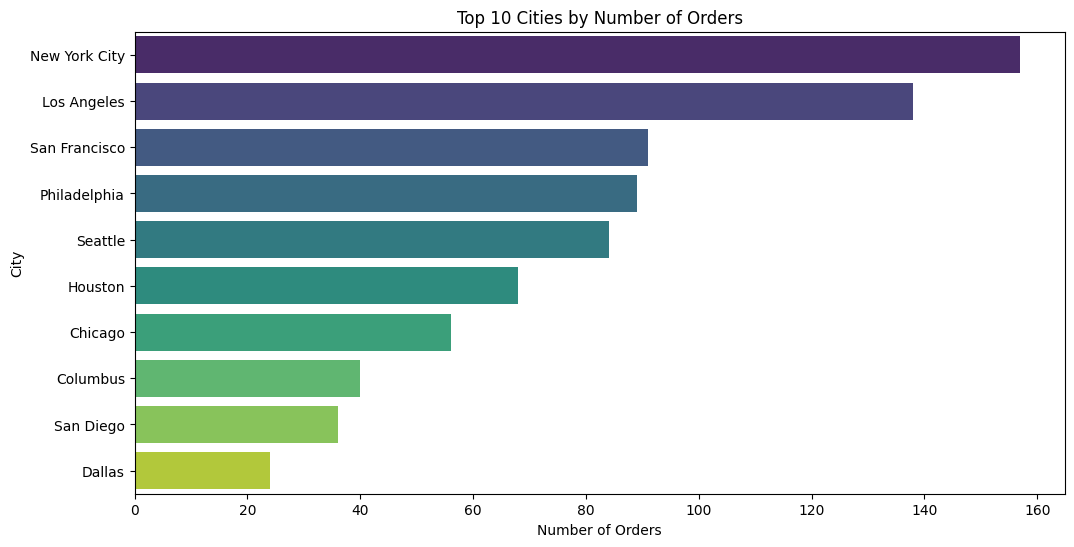

In [34]:

# Count unique orders per city
city_orders = df.groupby("City")["Order ID"].nunique().reset_index()

# Sort in descending order
city_orders = city_orders.sort_values(by="Order ID", ascending=False)

print("Orders by City:\n", city_orders.head(10))

# Visualization
plt.figure(figsize=(12,6))
sns.barplot(x="Order ID", y="City", data=city_orders.head(10), palette="viridis")
plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("City")
plt.show()


###  Which Sub-Category has the highest sales?

Sales by Sub-Category:
   Sub-Category        Sales
1       Chairs  328449.1030
3       Tables  206965.5320
0    Bookcases  114879.9963
2  Furnishings   91705.1640


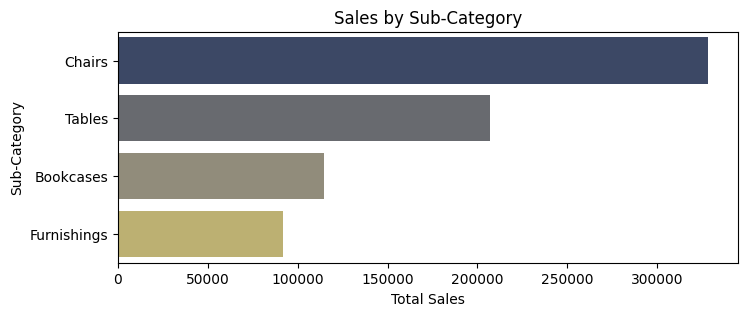

In [35]:

subcat_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index()

# Sort in descending order
subcat_sales = subcat_sales.sort_values(by="Sales", ascending=False)

print("Sales by Sub-Category:\n", subcat_sales)

# Visualization

plt.figure(figsize=(8,3))
sns.barplot(x="Sales", y="Sub-Category", data=subcat_sales, palette="cividis")
plt.title("Sales by Sub-Category")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()


###  Monthly Sales Trend

Monthly Sales Trend:
    YearMonth      Sales
0 2014-01-01   6242.525
1 2014-02-01   1839.658
2 2014-03-01  14573.956
3 2014-04-01   7944.837
4 2014-05-01   6912.787


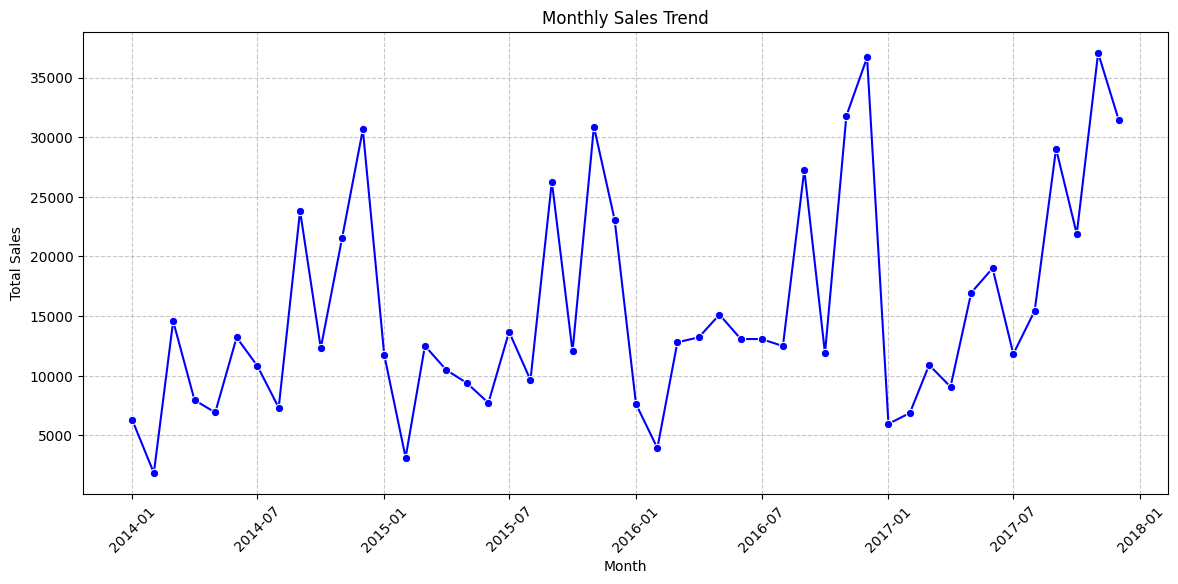

In [36]:
# Year-Month
df["YearMonth"] = df["Order Date"].dt.to_period("M")

# Monthly Sales 
monthly_sales = df.groupby("YearMonth")["Sales"].sum().reset_index()

# Convert YearMonth back to timestamp
monthly_sales["YearMonth"] = monthly_sales["YearMonth"].dt.to_timestamp()

print("Monthly Sales Trend:\n", monthly_sales.head())

# Visualization
plt.figure(figsize=(14,6))
sns.lineplot(x="YearMonth", y="Sales", data=monthly_sales, marker="o", color="blue")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()




### Top 10 Customers by Sales

Top 10 Customers by Sales:

        Customer Name      Sales
613      Seth Vernon  8332.0900
337       Joe Elijah  6920.1360
538     Peter Fuller  6837.3480
116  Caroline Jumper  6267.1940
279        Greg Tran  6219.2600
399  Laura Armstrong  5387.3900
677     Tom Prescott  4899.1208
514       Nora Preis  4839.6585
91     Brenda Bowman  4768.4980
79    Bill Donatelli  4513.1130


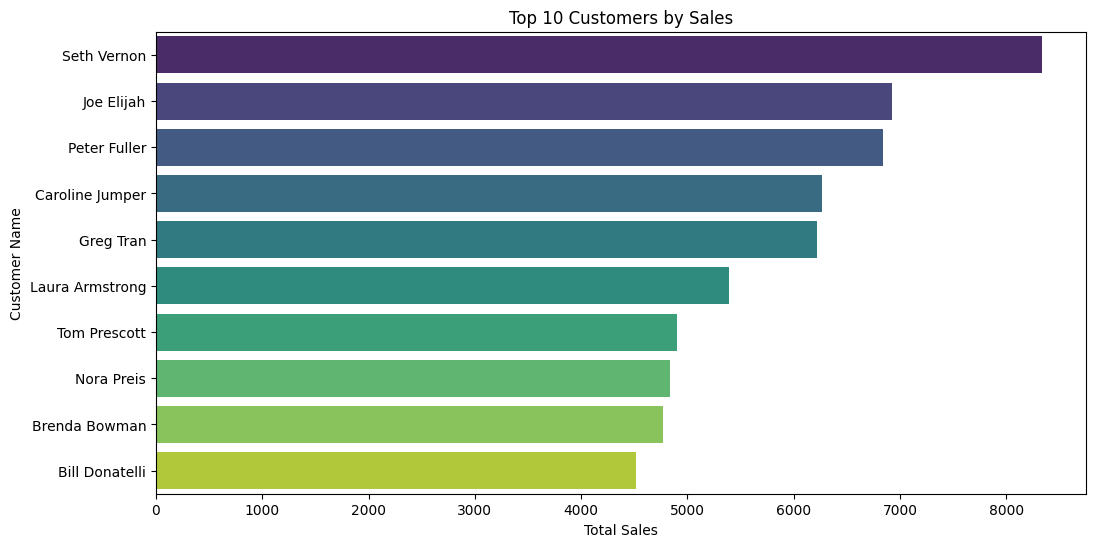

In [37]:


top_customers = df.groupby("Customer Name")["Sales"].sum().reset_index().sort_values(by="Sales", ascending=False).head(10)

print("Top 10 Customers by Sales:\n\n", top_customers)

# Visualization

plt.figure(figsize=(12,6))
sns.barplot(x="Sales", y="Customer Name", data=top_customers, palette="viridis")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.show()


### Region-wise Sales Contribution

Region-wise Sales Contribution:
     Region        Sales    Sales %
3     West  252612.7435  34.044854
1     East  208291.2040  28.071599
0  Central  163797.1638  22.075096
2    South  117298.6840  15.808452


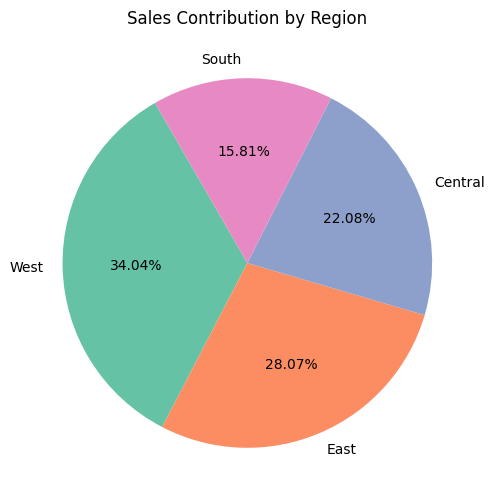

In [38]:

region_sales = df.groupby("Region")["Sales"].sum().reset_index()

# Calculate percentage
region_sales["Sales %"] = (region_sales["Sales"] / region_sales["Sales"].sum()) * 100

# Sort by percentage
region_sales = region_sales.sort_values(by="Sales %", ascending=False)

print("Region-wise Sales Contribution:\n", region_sales)

# Visualization

plt.figure(figsize=(8,6))
plt.pie(region_sales["Sales"], labels=region_sales["Region"], autopct="%.2f%%", startangle=120, colors=sns.color_palette("Set2"))
plt.title("Sales Contribution by Region")
plt.show()


### Which Region contributes the most to total sales?

Region-wise Sales:
     Region        Sales
3     West  252612.7435
1     East  208291.2040
0  Central  163797.1638
2    South  117298.6840


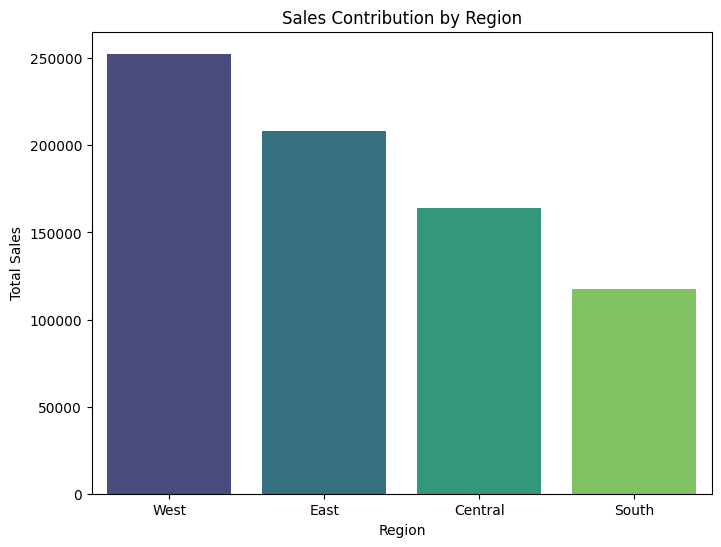

In [39]:
# Group sales by Region
region_sales = df.groupby("Region")["Sales"].sum().reset_index()

# Sort descending
region_sales = region_sales.sort_values(by="Sales", ascending=False)

print("Region-wise Sales:\n", region_sales)

# Visualization
plt.figure(figsize=(8,6))
sns.barplot(x="Region", y="Sales", data=region_sales, palette="viridis")
plt.title("Sales Contribution by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()


### Which Sub-Category contributes the most to sales?

Sub-Category wise Sales:
   Sub-Category        Sales
1       Chairs  328449.1030
3       Tables  206965.5320
0    Bookcases  114879.9963
2  Furnishings   91705.1640


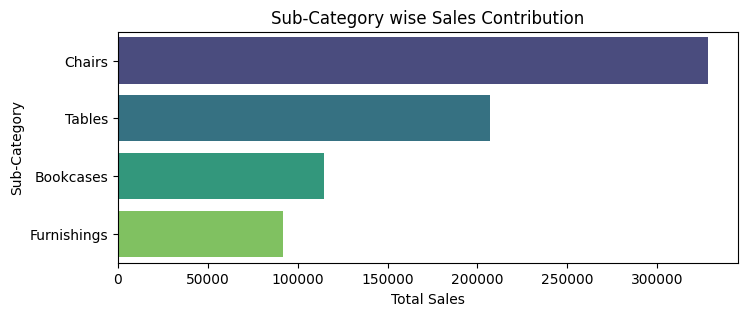

In [151]:
# Group sales by Sub-Category
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().reset_index().sort_values(by="Sales", ascending=False)

print("Sub-Category wise Sales:\n", subcategory_sales)

# Visualization (Bar Plot)
plt.figure(figsize=(8,3))
sns.barplot(x="Sales", y="Sub-Category", data=subcategory_sales, palette="viridis")
plt.title("Sub-Category wise Sales Contribution")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()



### Which Ship Mode is most used by customers?

Ship Mode Usage:
         Ship Mode  Order Count
0  Standard Class         1248
1    Second Class          427
2     First Class          327
3        Same Day          119


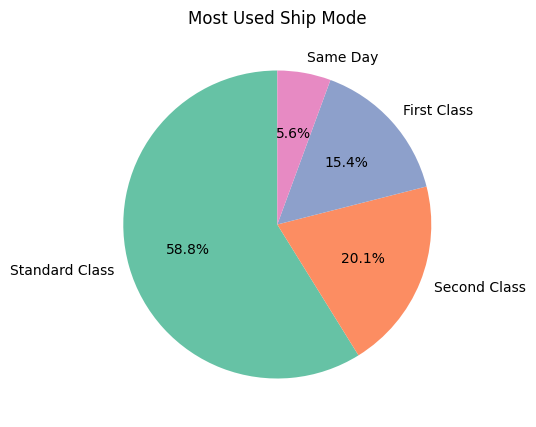

In [152]:
# Count number of orders by Ship Mode
shipmode_counts = df["Ship Mode"].value_counts().reset_index()
shipmode_counts.columns = ["Ship Mode", "Order Count"]

print("Ship Mode Usage:\n", shipmode_counts)

# Visualization (Pie Chart)
plt.figure(figsize=(5,5))
plt.pie(shipmode_counts["Order Count"], labels=shipmode_counts["Ship Mode"], autopct="%1.1f%%", startangle=90, colors=sns.color_palette("Set2"))
plt.title("Most Used Ship Mode")
plt.show()



### Which Customer made the highest purchase (by Sales)?

Top Customer by Sales:
 Customer Name    Seth Vernon
Sales                8332.09
Name: 613, dtype: object


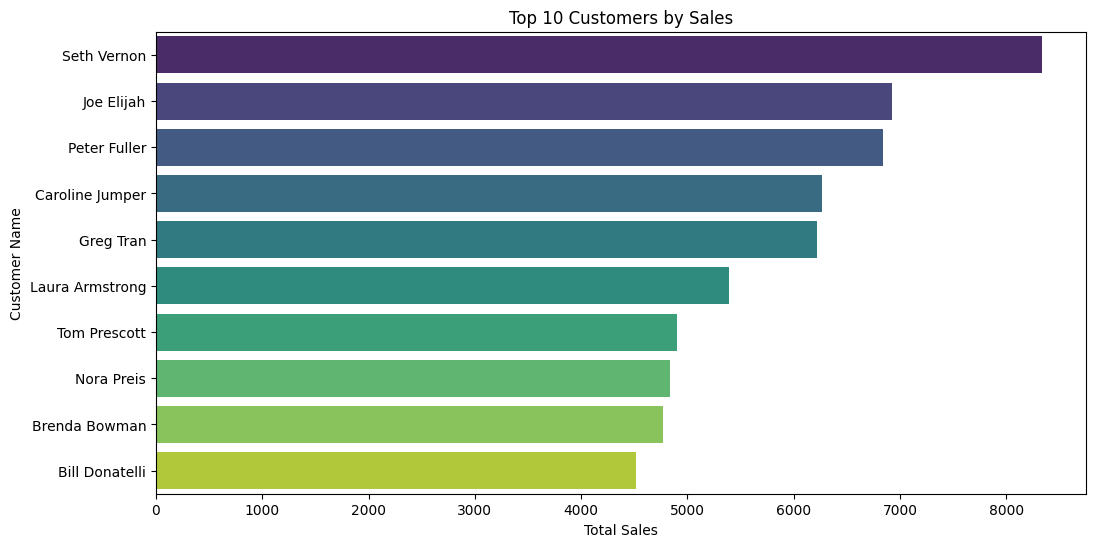

In [41]:
# Total sales by each customer
customer_sales = df.groupby("Customer Name")["Sales"].sum().reset_index()

# Sort descending
customer_sales = customer_sales.sort_values(by="Sales", ascending=False)

# Top customer
top_customer = customer_sales.iloc[0]

print("Top Customer by Sales:\n", top_customer)

# Visualization (Top 10 customers by Sales)
plt.figure(figsize=(12,6))
sns.barplot(data=customer_sales.head(10), x="Sales", y="Customer Name", palette="viridis")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer Name")
plt.show()


### Which Customer made the highest number of Orders?

Top Customer by Number of Orders:
 Customer Name    Seth Vernon
Order ID                   9
Name: 613, dtype: object


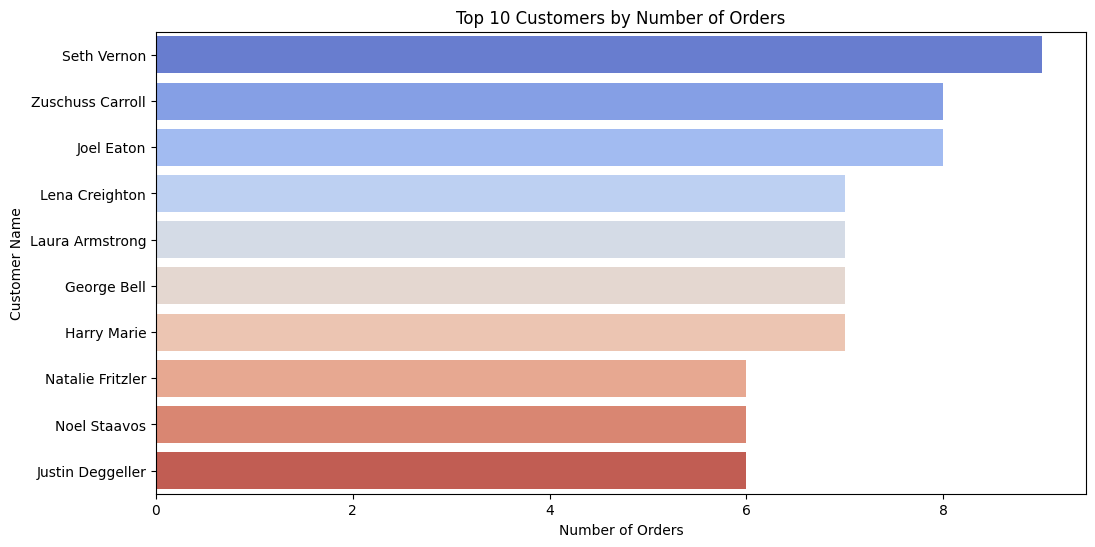

In [42]:
# Count number of orders placed by each customer
customer_orders = df.groupby("Customer Name")["Order ID"].nunique().reset_index()

# Sort descending
customer_orders = customer_orders.sort_values(by="Order ID", ascending=False)

# Top customer
top_customer_orders = customer_orders.iloc[0]

print("Top Customer by Number of Orders:\n", top_customer_orders)

# Visualization (Top 10 customers by Orders)
plt.figure(figsize=(12,6))
sns.barplot(data=customer_orders.head(10), x="Order ID", y="Customer Name", palette="coolwarm")
plt.title("Top 10 Customers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Customer Name")
plt.show()


### Yearly Sales Growth Trend

Yearly Sales Growth:
    Year        Sales
0  2014  157192.8531
1  2015  170518.2370
2  2016  198901.4360
3  2017  215387.2692


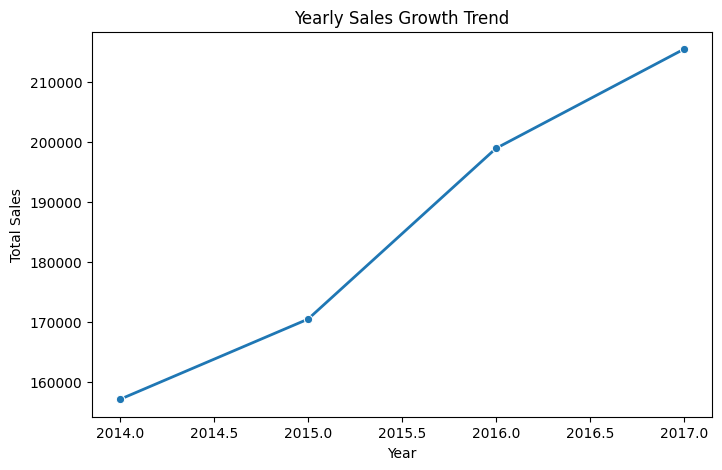

In [153]:

# Extract Year
df["Year"] = df["Order Date"].dt.year

# Group by Year and calculate total Sales
yearly_sales = df.groupby("Year")["Sales"].sum().reset_index()

print("Yearly Sales Growth:\n", yearly_sales)

# Visualization
plt.figure(figsize=(8,5))
sns.lineplot(data=yearly_sales, x="Year", y="Sales", marker="o", linewidth=2)
plt.title("Yearly Sales Growth Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()


### Sales Contribution by Ship Mode

Sales Contribution by Ship Mode:
         Ship Mode        Sales    Sales %
0     First Class  110730.5229  14.923255
1        Same Day   39148.7790   5.276117
2    Second Class  156289.0244  21.063217
3  Standard Class  435831.4690  58.737411


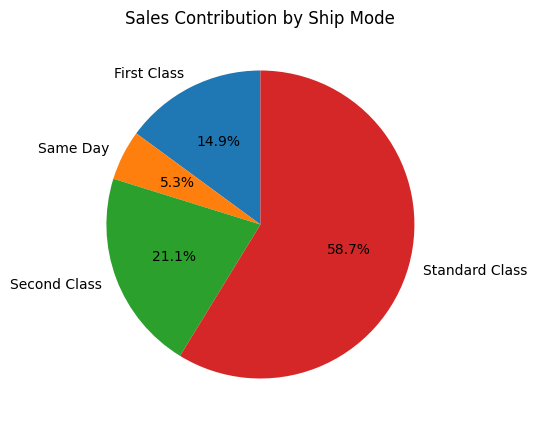

In [154]:
# Group by Ship Mode and calculate total sales
shipmode_sales = df.groupby("Ship Mode")["Sales"].sum().reset_index()

# Calculate percentage contribution
shipmode_sales["Sales %"] = (shipmode_sales["Sales"] / shipmode_sales["Sales"].sum()) * 100

print("Sales Contribution by Ship Mode:\n", shipmode_sales)

# Visualization
plt.figure(figsize=(7,5))
plt.pie(shipmode_sales["Sales"], labels=shipmode_sales["Ship Mode"], autopct="%.1f%%", startangle=90)
plt.title("Sales Contribution by Ship Mode")
plt.show()


In [45]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'YearMonth', 'Year'],
      dtype='object')

In [46]:

df1 = df[['Order Date','Sales','Quantity','Discount','Profit']]
df1 

,Order Date,Sales,Quantity,Discount,Profit
0,2016-11-08,261.9600,2,0.00,41.9136
1,2016-11-08,731.9400,3,0.00,219.5820
2,2015-10-11,957.5775,5,0.45,-383.0310
3,2014-06-09,48.8600,7,0.00,14.1694
4,2014-06-09,1706.1840,9,0.20,85.3092
...,...,...,...,...,...
2116,2015-03-19,383.4656,4,0.32,-67.6704
2117,2016-12-05,13.4000,1,0.00,6.4320
2118,2015-09-06,85.9800,1,0.00,22.3548
2119,2014-01-21,25.2480,3,0.20,4.1028


In [47]:
df['Order Date'].value_counts().sum()

np.int64(2121)

In [48]:
df['Order Date'].isnull().sum()

np.int64(0)

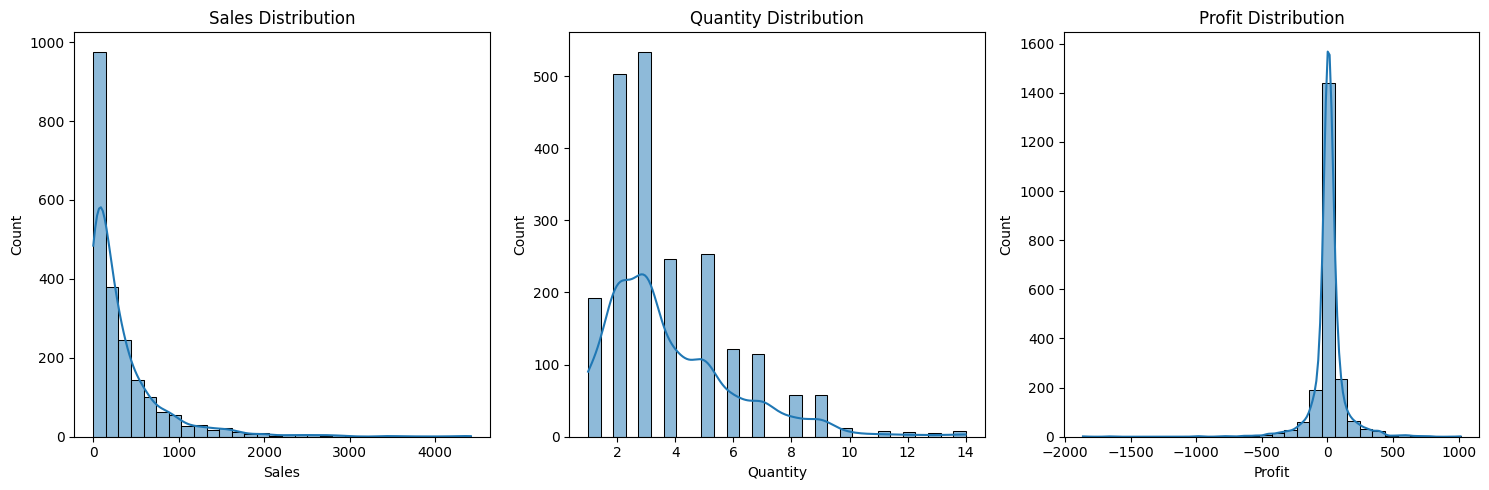

In [49]:
plt.figure(figsize=(15, 5))

# Sales Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['Sales'], bins=30, kde=True)
plt.title('Sales Distribution')

# Quantity Distribution
plt.subplot(1, 3, 2)
sns.histplot(df['Quantity'], bins=30, kde=True)
plt.title('Quantity Distribution')

# Profit Distribution
plt.subplot(1, 3, 3)
sns.histplot(df['Profit'], bins=30, kde=True)
plt.title('Profit Distribution')

plt.tight_layout()
plt.show()

In [50]:

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose  

from sklearn.model_selection import train_test_split

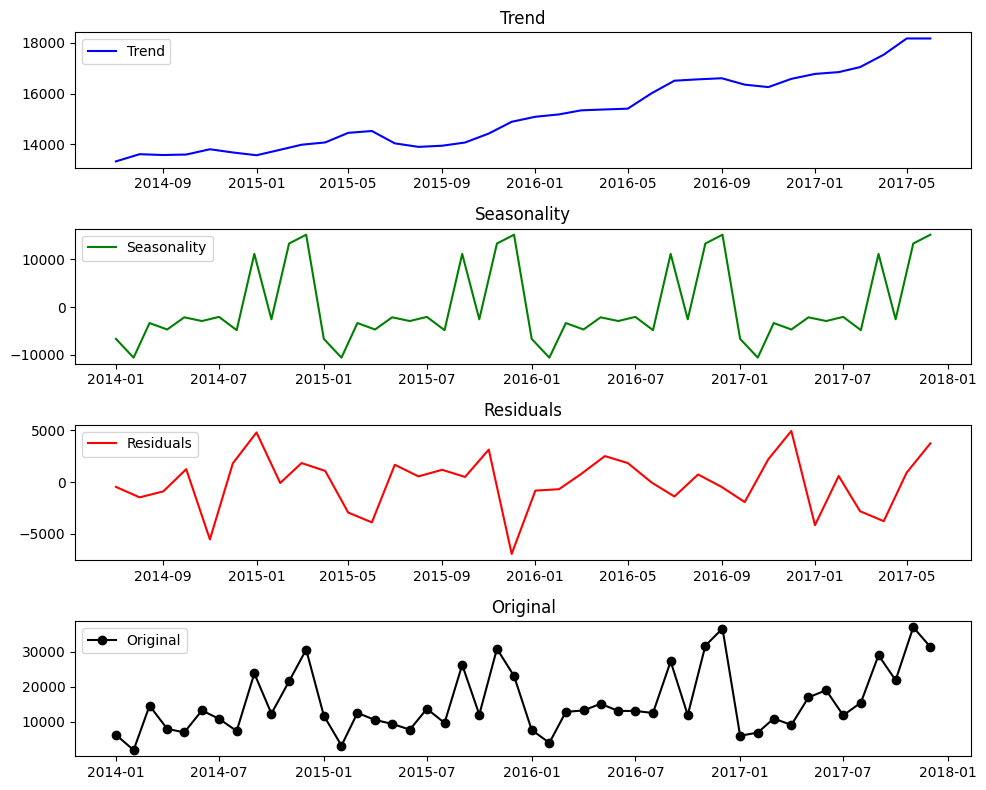

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

monthly_sales = monthly_sales.set_index("YearMonth")

# Seasonal Decomposition
decomposition = seasonal_decompose(monthly_sales["Sales"], model='additive', period=12)

# Plotting
plt.figure(figsize=(10,8))

plt.subplot(4, 1, 1)
plt.plot(decomposition.trend, label='Trend', color='blue')
plt.legend(loc='upper left')
plt.title('Trend')

plt.subplot(4, 1, 2)
plt.plot(decomposition.seasonal, label='Seasonality', color='green')
plt.legend(loc='upper left')
plt.title('Seasonality')

plt.subplot(4, 1, 3)
plt.plot(decomposition.resid, label='Residuals', color='red')
plt.legend(loc='upper left')
plt.title('Residuals')

plt.subplot(4, 1, 4)
plt.plot(monthly_sales.index, monthly_sales["Sales"], marker='o', linestyle='-', label='Original', color='black')
plt.legend(loc='upper left')
plt.title('Original')

plt.tight_layout()
plt.show()


### Decompose the time series into trend, seasonality, and residuals in additive model....

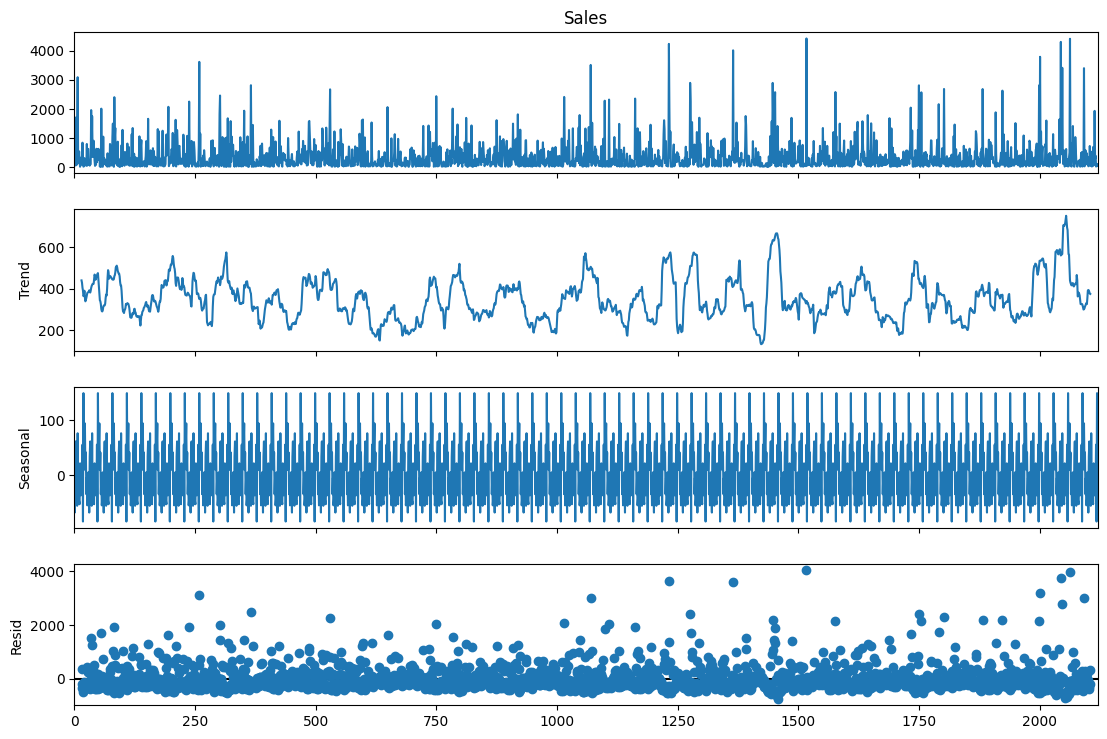

In [52]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Additive decomposition
decomposition = seasonal_decompose(df['Sales'], model='additive', period=30)  # 30 days seasonality

# Plot
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

### Decompose the time series into trend, seasonality, and residuals in multiplicativ model

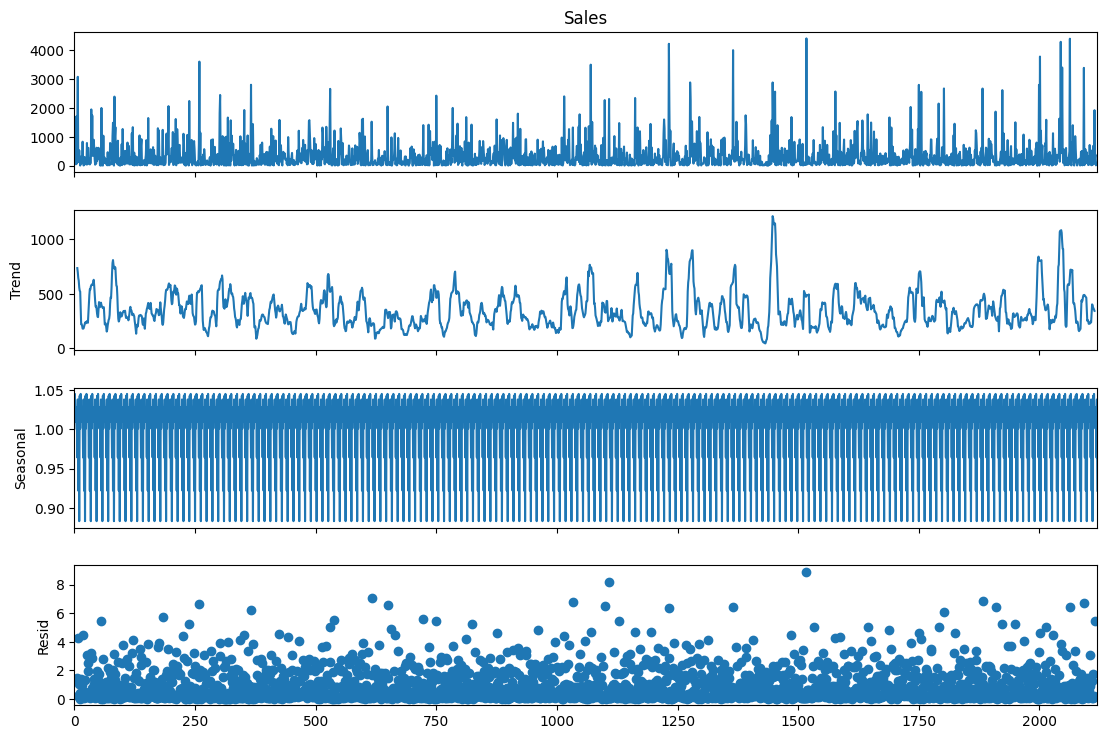

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Additive decomposition
decomposition = seasonal_decompose(df['Sales'], model='multiplicativ', period=12)  # 30 days seasonality

# Plot
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.show()

## ADF Test...

In [54]:
# Check for stationarity
from statsmodels.tsa.stattools import adfuller
adfuller_result = adfuller(monthly_sales)
print("ADF Statistic: %f" % adfuller_result[0])
print('p-value: %f' % adfuller_result[1])

ADF Statistic: -4.699026
p-value: 0.000085


#### The Augmented Dickey-Fuller (ADF) test statistic of -4.697056 with a p-value of 0.000085 suggests strong evidence against the null hypothesis (H0), leading to the rejection of the null hypothesis. This indicates that the data has no unit root and is stationary, implying that it does not exhibit a trend and its statistical properties remain constant over time.

A unit root is indicative of non-stationarity in the time series. Stationarity is a desirable property in time series analysis, as it implies that the statistical properties of the data, such as mean and variance, do not change over time. Non-stationarity, on the other hand, implies that the statistical properties of the data are time-dependent and may exhibit trends or patterns.

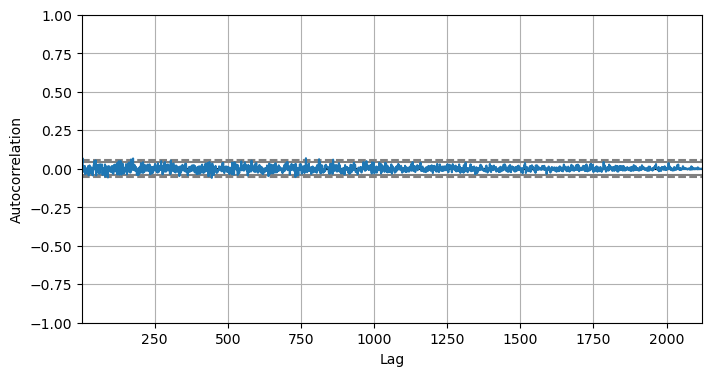

In [75]:
plt.figure(figsize=(8,4))
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['Sales'])
plt.show()

###  ACF & PACF....

* The ACF measures the correlation between a variable's current value and its past values at different lags, while the PACF measures the correlation between a variable's current value and its past values after removing the effect of intervening observations.

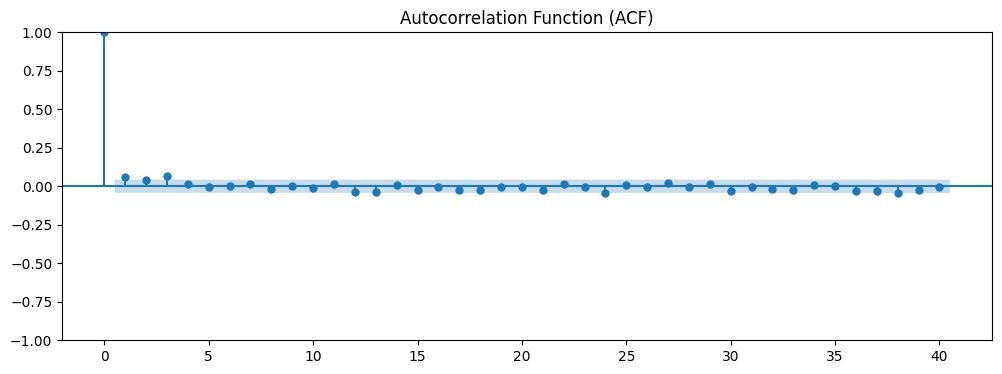

In [55]:
import statsmodels.api as sm

# Plot ACF
fig, ax1 = plt.subplots(figsize=(12, 4))
sm.graphics.tsa.plot_acf(df['Sales'], lags=40, ax=ax1)
plt.title('Autocorrelation Function (ACF)')
plt.show()


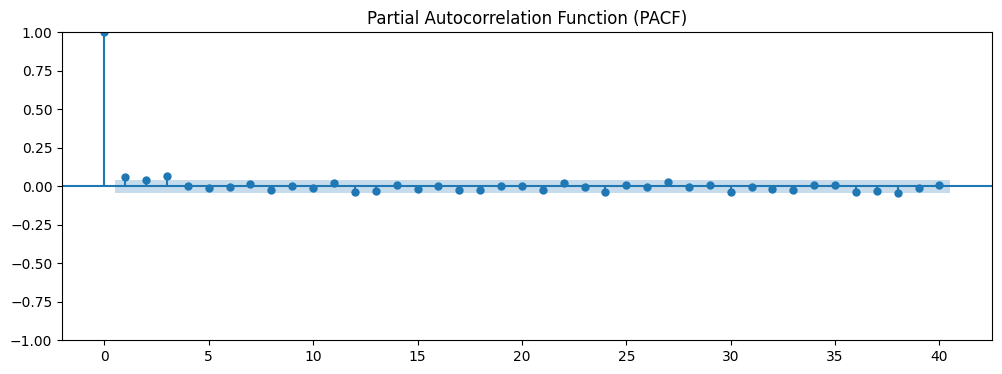

In [56]:
# Plot PACF
fig, ax2 = plt.subplots(figsize=(12, 4))
sm.graphics.tsa.plot_pacf(df['Sales'], lags=40, ax=ax2)
plt.title('Partial Autocorrelation Function (PACF)')

plt.show()

### Model Building....

In [57]:
# Split data into train and test sets
import numpy as np
X = np.arange(len(monthly_sales)).reshape(-1, 1)
y = monthly_sales.values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [58]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Fit ARIMA model
arima_model = ARIMA(y_train, order=(5,1,0))
arima_model_fit = arima_model.fit()

# Fit SARIMA model
sarima_model = SARIMAX(y_train, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
sarima_model_fit = sarima_model.fit()

In [59]:
arima_model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                   38
Model:                 ARIMA(5, 1, 0)   Log Likelihood                -389.499
Date:                Sun, 07 Dec 2025   AIC                            790.998
Time:                        22:50:38   BIC                            800.664
Sample:                             0   HQIC                           794.406
                                 - 38                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5997      0.244     -2.455      0.014      -1.079      -0.121
ar.L2         -0.4841      0.293     -1.653      0.098      -1.058       0.090
ar.L3         -0.2184      0.315     -0.692      0.489      -0.837       0.400
ar.L4         -0.2718      0.394     -0.690      0.490      -1.043       0.500
ar.L5         -0.3314      0.247     -1.340      0.180      -0.816       0.153
sigma2        8.6e+07   1.14e-09   7.56e+16      0.000     8.6e+07     8.6e+07
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 0.90
Prob(Q):                              0.95   Prob(JB):                         0.64
Heteroskedasticity (H):               1.81   Skew:                             0.20
Prob(H) (two-sided):                  0.32   Kurtosis:                         2.35
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 3.36e+33. Standard errors may be unstable.
"""

In [60]:
sarima_model_fit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                   38
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -250.016
Date:                            Sun, 07 Dec 2025   AIC                            510.032
Time:                                    22:50:40   BIC                            516.126
Sample:                                         0   HQIC                           511.722
                                             - 38                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4795      0.200      2.400      0.016       0.088       0.871
ma.L1         -0.8596      0.175     -4.918      0.000      -1.202      -0.517
ar.S.L12      -0.9850      0.175     -5.617      0.000      -1.329      -0.641
ma.S.L12       0.9021      0.588      1.534      0.125      -0.251       2.055
sigma2      2.605e+07   3.47e-08   7.51e+14      0.000     2.6e+07     2.6e+07
===================================================================================
Ljung-Box (L1) (Q):                   4.31   Jarque-Bera (JB):                 0.39
Prob(Q):                              0.04   Prob(JB):                         0.82
Heteroskedasticity (H):               0.80   Skew:                             0.22
Prob(H) (two-sided):                  0.76   Kurtosis:                         2.57
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 7.15e+30. Standard errors may be unstable.
"""

### Forcasting


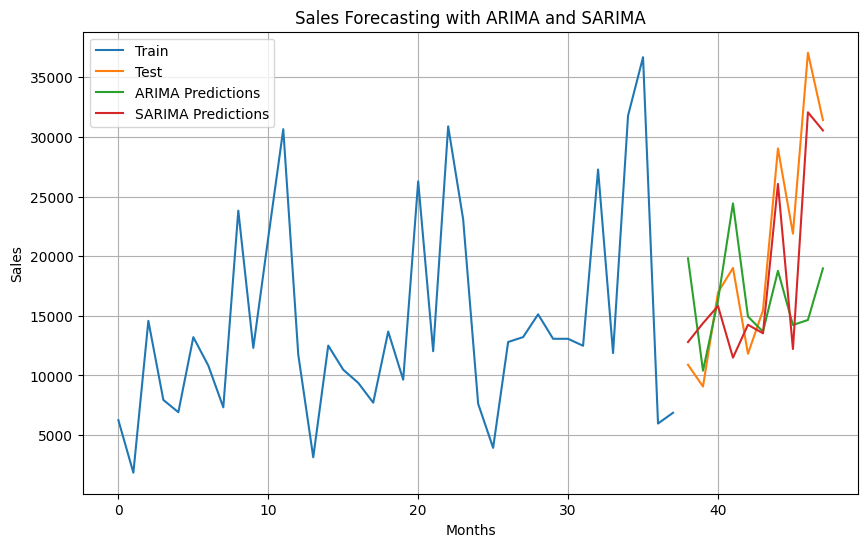

In [ ]:
arima_predictions = arima_model_fit.forecast(steps=len(X_test))
sarima_predictions = sarima_model_fit.forecast(steps=len(X_test))
# Plot predictions
plt.figure(figsize=(10, 6))
plt.plot(X_train, y_train, label='Train')
plt.plot(X_test, y_test, label='Test')
plt.plot(X_test, arima_predictions, label='ARIMA Predictions')
plt.plot(X_test, sarima_predictions, label='SARIMA Predictions')
plt.title('Sales Forecasting with ARIMA and SARIMA')
plt.xlabel('Months')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.show()

##### From the plot, it appears that the SARIMA model (red line) provides better forecasts compared to the ARIMA model (green line). The SARIMA predictions closely follow the actual sales trend, capturing both the overall pattern and the peaks in the data more accurately than the ARIMA model. This suggests that the SARIMA model, which incorporates seasonality into its forecasting process, is more suitable for capturing the complex patterns present in the sales data.